<a href="https://www.kaggle.com/code/nithinreddy600/notebook870991d19e?scriptVersionId=320519544" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Q9. How does the Global Currency Tracker show the role of USD in international payments?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Change DATA_PATH only if your CSV files are stored somewhere else.
# This works in Kaggle; the fallback works when the notebook and CSV are in the same folder.
DATA_PATH = Path("/kaggle/input/datasets/nithinreddy600/dbs-research")
if not DATA_PATH.exists():
    DATA_PATH = Path(".")

OUTPUT_PATH = Path("/kaggle/working")
if not OUTPUT_PATH.exists():
    OUTPUT_PATH = Path(".")
OUTPUT_PATH.mkdir(exist_ok=True)

swift = pd.read_csv(DATA_PATH / "swift_currency_tracker_all_reports.csv")
swift.columns = swift.columns.astype(str).str.strip()

print("SWIFT dataset loaded:", swift.shape)
print("Columns:")
for i, c in enumerate(swift.columns):
    print(i, repr(c))

display(swift.head())


SWIFT dataset loaded: (288, 9)
Columns:
0 'report_month'
1 'data_month'
2 'source_report_name'
3 'metric'
4 'category'
5 'currency_or_economy'
6 'value'
7 'unit'
8 'notes'


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,Rank 5


In [2]:
def find_col(df, keywords):
    for key in keywords:
        matches = [c for c in df.columns if key.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

value_col = "value"
currency_col = "currency_or_economy"
metric_col = "metric"
category_col = "category"
month_col = "data_month"
report_month_col = "report_month"
unit_col = "unit"

# Clean value column
swift[value_col] = (
    swift[value_col].astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
)
swift[value_col] = pd.to_numeric(swift[value_col], errors="coerce")

# IMPORTANT: specify exact month format to remove pandas warning.
# Example values in this dataset: "December 2025", "March 2026"
swift["data_month_dt"] = pd.to_datetime(swift[month_col], format="%B %Y", errors="coerce")
swift["report_month_dt"] = pd.to_datetime(swift[report_month_col], format="%B %Y", errors="coerce")

# Show full dataset coverage clearly
start_month = swift["data_month_dt"].min()
end_month = swift["data_month_dt"].max()
dataset_period = f"{start_month.strftime('%B %Y')} to {end_month.strftime('%B %Y')}"

# For Q9, use the latest available data month for the chart
analysis_month = end_month.strftime("%B %Y")
analysis_period = f"{analysis_month} (latest available month; dataset covers {dataset_period})"

print("Dataset period:", dataset_period)
print("Analysis month used in chart:", analysis_month)

# Filter only Global Payment Share rows for the latest data month
work = swift[
    (swift["data_month_dt"] == end_month) &
    (swift[metric_col].astype(str).str.strip().eq("Global Payment Share")) &
    (swift[category_col].astype(str).str.strip().eq("Currency Ranking"))
].copy()

ranking = work[[currency_col, value_col, "notes", month_col, report_month_col]].dropna(subset=[currency_col, value_col])
ranking = ranking.sort_values(value_col, ascending=False)

top10 = ranking.head(10)
display(top10)
top10.to_csv(OUTPUT_PATH / "Q9_top10_global_payment_currencies.csv", index=False)

usd_rows = ranking[ranking[currency_col].astype(str).str.upper().eq("USD")]
display(usd_rows)
usd_rows.to_csv(OUTPUT_PATH / "Q9_USD_value_or_rank.csv", index=False)


Dataset period: December 2025 to March 2026
Analysis month used in chart: March 2026


,currency_or_economy,value,notes,data_month,report_month
146,USD,51.14,Rank 1,March 2026,April 2026
147,EUR,21.30,Rank 2,March 2026,April 2026
148,GBP,6.54,Rank 3,March 2026,April 2026
149,JPY,3.53,Rank 4,March 2026,April 2026
150,CNY,3.10,Rank 5,March 2026,April 2026
151,CAD,3.03,Rank 6,March 2026,April 2026
152,HKD,1.76,Rank 7,March 2026,April 2026
153,AUD,1.61,Rank 8,March 2026,April 2026
154,SGD,1.23,Rank 9,March 2026,April 2026
155,CHF,1.07,Rank 10,March 2026,April 2026


,currency_or_economy,value,notes,data_month,report_month
146,USD,51.14,Rank 1,March 2026,April 2026


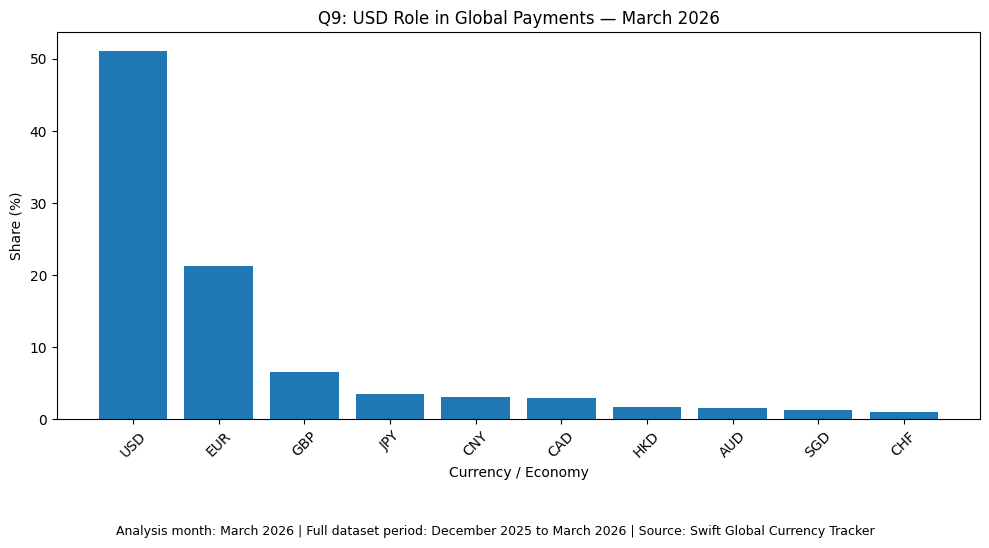

In [3]:
plt.figure(figsize=(10,5))
plt.bar(top10[currency_col].astype(str), top10[value_col])

plt.title(f"Q9: USD Role in Global Payments — {analysis_month}")
plt.xlabel("Currency / Economy")
plt.ylabel("Share (%)")
plt.xticks(rotation=45)

# This note makes the month/year and dataset coverage clear in the exported chart.
plt.figtext(
    0.5, -0.08,
    f"Analysis month: {analysis_month} | Full dataset period: {dataset_period} | Source: Swift Global Currency Tracker",
    ha="center", fontsize=9
)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "Q9_top10_global_payment_currencies_correct_month_year.png", dpi=300, bbox_inches="tight")
plt.show()


## Short answer

The analysis uses the latest available **data month: March 2026**.  
The full CSV dataset available for this notebook covers **December 2025 to March 2026**.

For March 2026, the Global Currency Tracker shows that USD has the highest global payment share among the listed currencies. Therefore, USD remains the dominant currency in global/international payments.
